In [6]:
import seaborn as sns
import pandas as pd

In [7]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [8]:
titanic = pd.read_csv('train.csv')

In [9]:
flights = sns.load_dataset('flights')

In [10]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [11]:
iris = sns.load_dataset('iris')

In [12]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# Scatterplot ( Numerical - Numerical)

<Axes: xlabel='total_bill', ylabel='tip'>

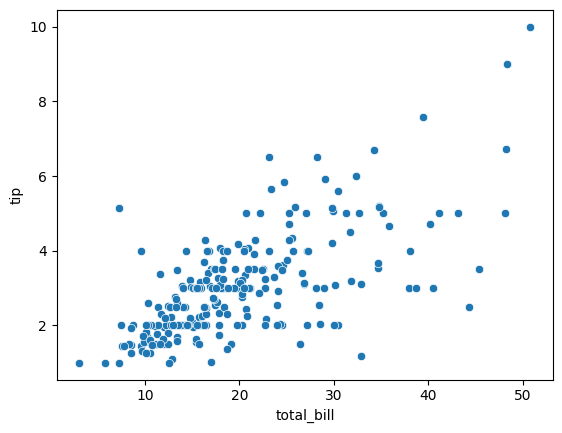

In [13]:
sns.scatterplot(x='total_bill',y='tip',data=tips)

<Axes: xlabel='total_bill', ylabel='tip'>

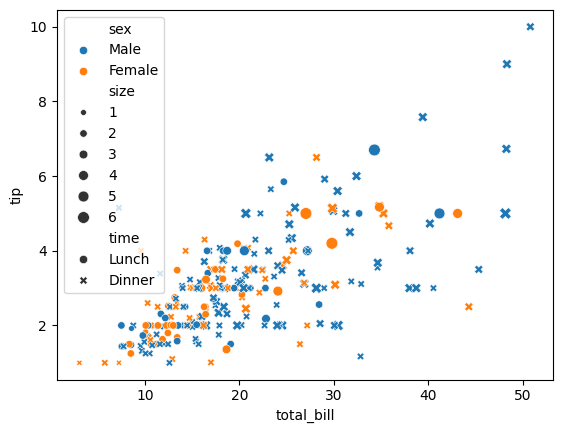

In [14]:
sns.scatterplot(x='total_bill',y='tip',data=tips,hue='sex',style='time', size='size')

# Barplot ( Numerical - Categorical)

<Axes: xlabel='Pclass', ylabel='Age'>

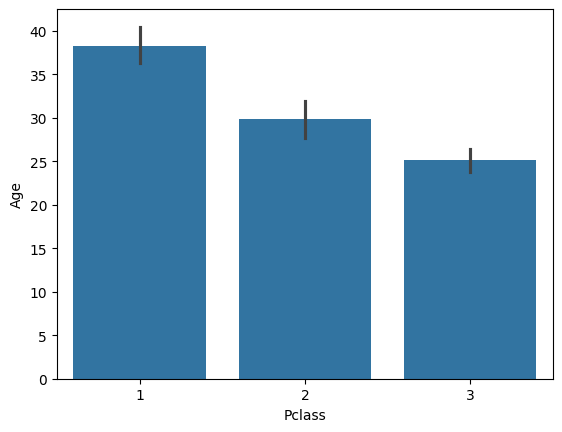

In [15]:
sns.barplot(x='Pclass', y='Age', data=titanic)

<Axes: xlabel='Pclass', ylabel='Fare'>

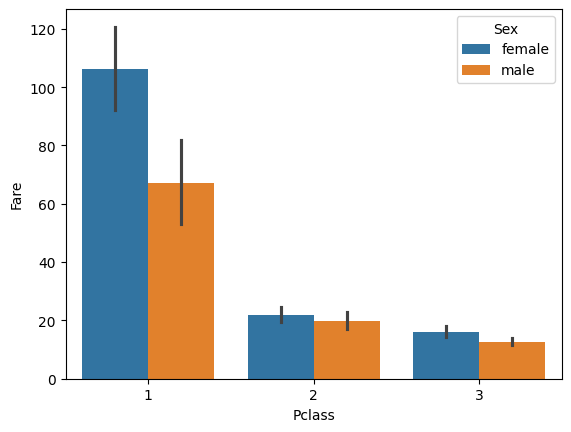

In [16]:
sns.barplot(x='Pclass', y='Fare', data=titanic, hue='Sex')

# Boxplot ( numerical - categorical)

<Axes: xlabel='Sex', ylabel='Age'>

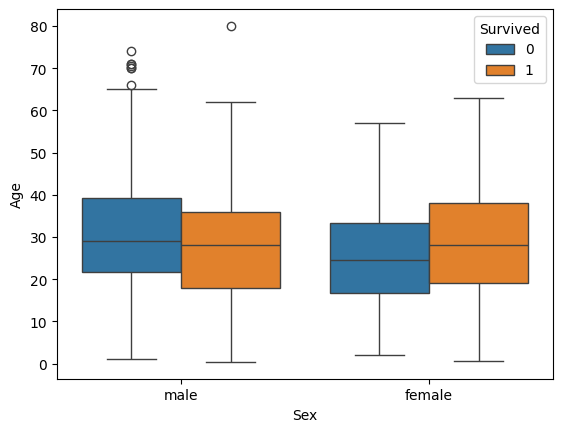

In [17]:
sns.boxplot(x='Sex',y='Age',data= titanic, hue='Survived')

# Distplot (Numerical - Categorical)

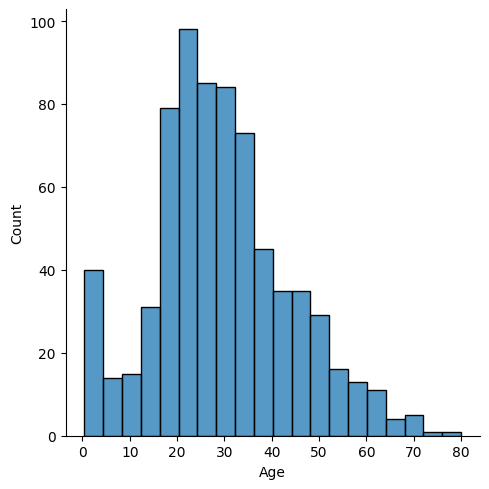

In [18]:

sns.displot(data=titanic, x='Age', bins=20, fill=True, kde=False)  # kde=True adds density curve


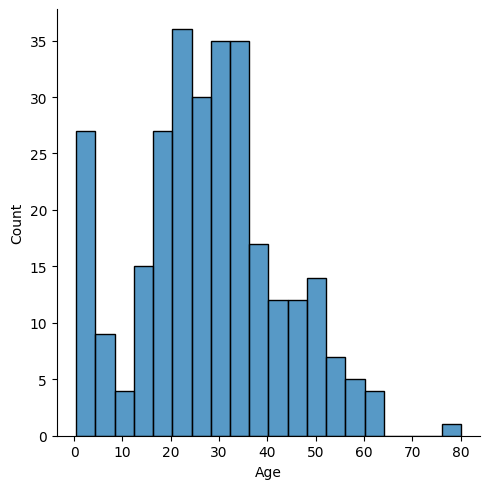

In [19]:
sns.displot(data=titanic[titanic['Survived']==1], x='Age', bins=20, fill=True, kde=False)  # kde=True adds density curve


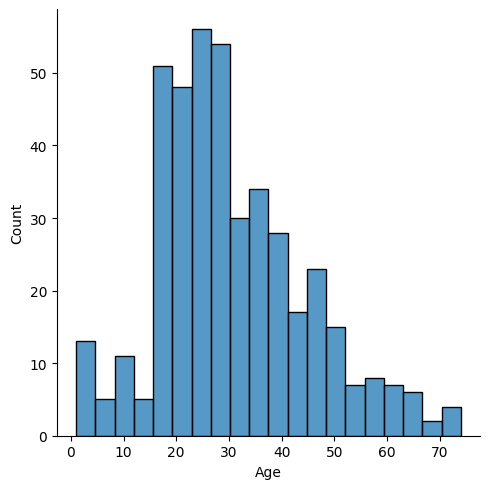

In [20]:
sns.displot(data=titanic[titanic['Survived']==0], x='Age', bins=20, fill=True, kde=False,)  # kde=True adds density curve



# HeatMap (Categorical - Categorical)

In [21]:
pd.crosstab(titanic['Pclass'],titanic['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


<Axes: xlabel='Survived', ylabel='Pclass'>

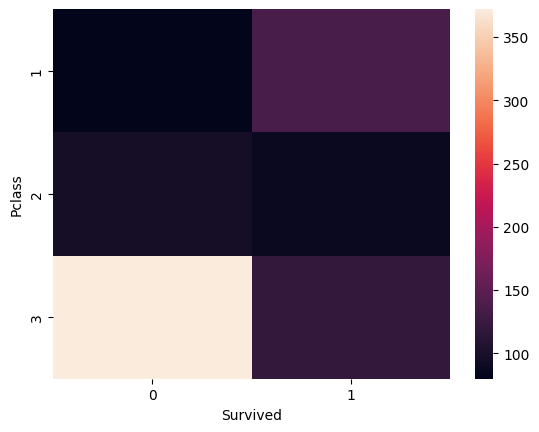

In [22]:
sns.heatmap(pd.crosstab(titanic['Pclass'],titanic['Survived']))

This is just giving the numbers, to get by percentage

In [23]:
# titanic.groupby('Pclass').mean()['Survived'] type error 
titanic['Survived'] = titanic['Survived'].astype(int)
print(titanic['Survived'].dtype)

int64


In [24]:
survival_rates = titanic.groupby('Pclass')['Survived'].mean()


In [25]:
print(survival_rates)

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


# Cluster Map ( Categorical - Categorical)

In [26]:
pd.crosstab(titanic['Parch'],titanic['Survived'])

Survived,0,1
Parch,,
0,445,233
1,53,65
2,40,40
3,2,3
4,4,0
5,4,1
6,1,0


In [27]:
pip install scipy


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


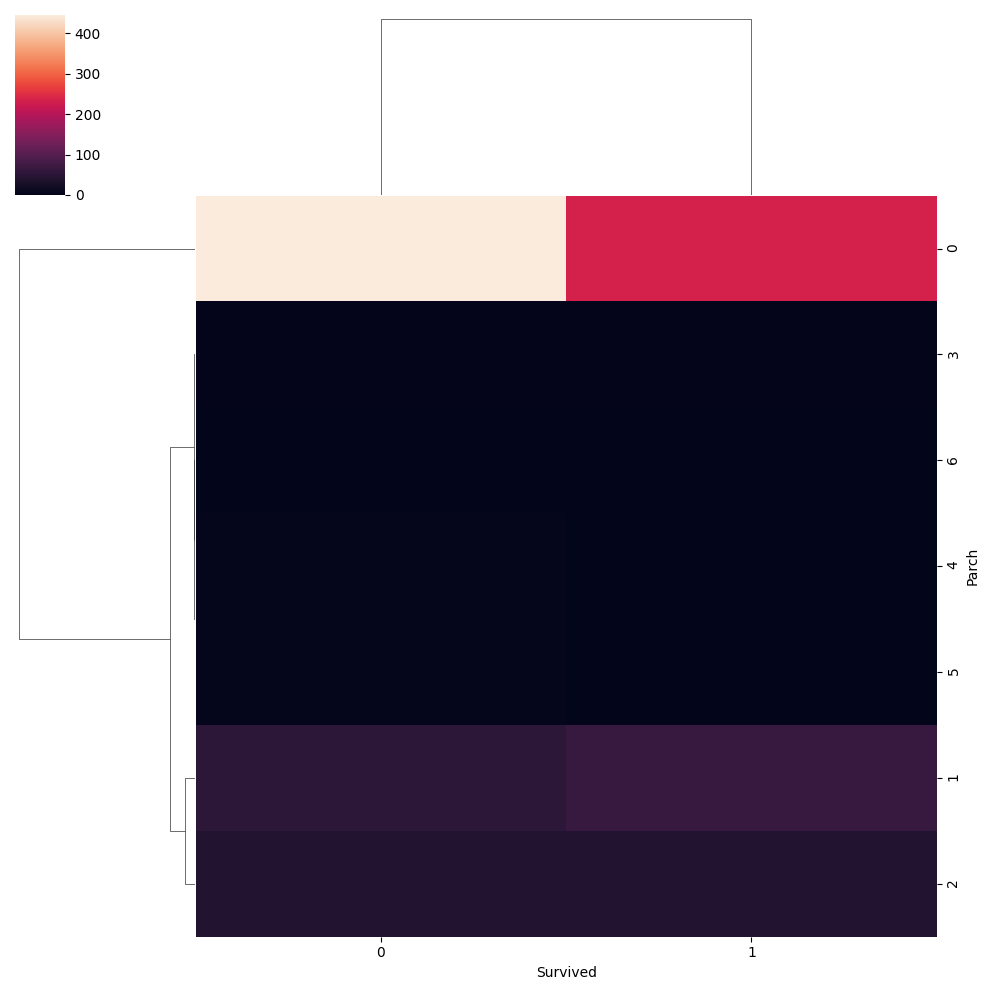

In [28]:
sns.clustermap(pd.crosstab(titanic['Parch'],titanic['Survived']))

# Pairplot

coll of scatterplots

In [29]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


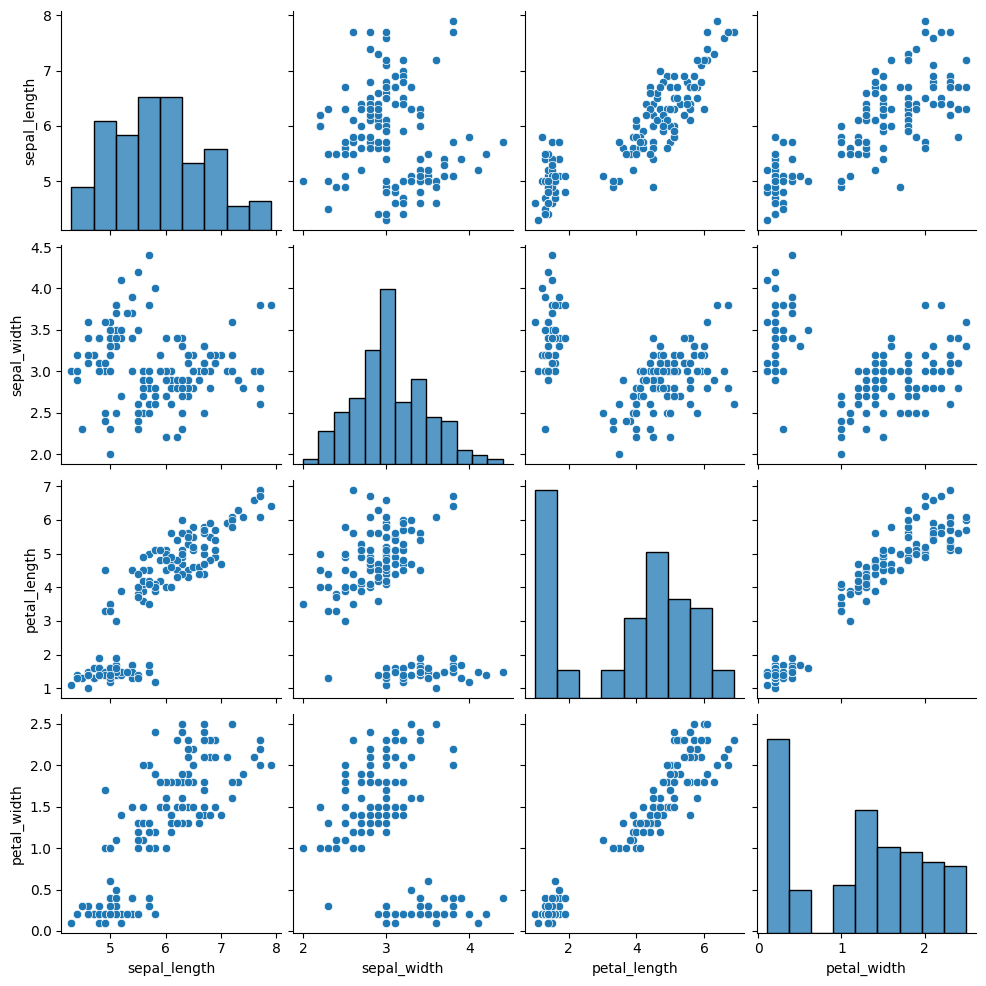

In [30]:
sns.pairplot(iris)

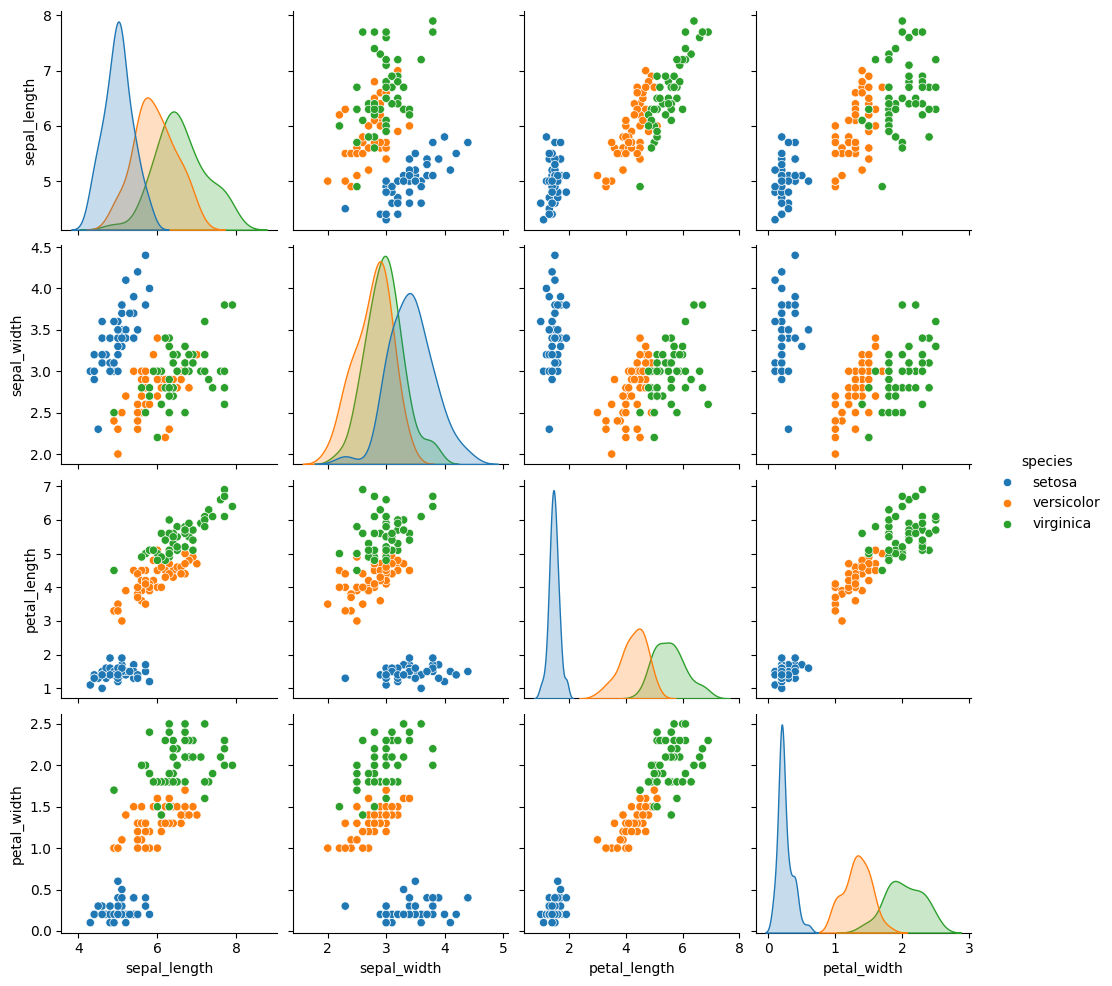

In [32]:
sns.pairplot(iris, hue='species')

#LinePlot ( Numerical - Numerical)

In [33]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [38]:
flights_grouped = flights.groupby('year').sum(numeric_only=True).reset_index()

In [39]:
flights_grouped

,year,passengers
0,1949,1520
1,1950,1676
2,1951,2042
3,1952,2364
4,1953,2700
5,1954,2867
6,1955,3408
7,1956,3939
8,1957,4421
9,1958,4572


<Axes: xlabel='year', ylabel='passengers'>

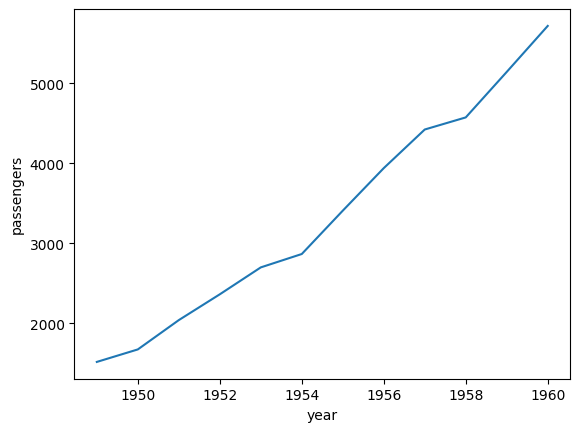

In [41]:
sns.lineplot(data=flights_grouped,x='year',y='passengers')

In [42]:
flights_grouped


,year,passengers
0,1949,1520
1,1950,1676
2,1951,2042
3,1952,2364
4,1953,2700
5,1954,2867
6,1955,3408
7,1956,3939
8,1957,4421
9,1958,4572


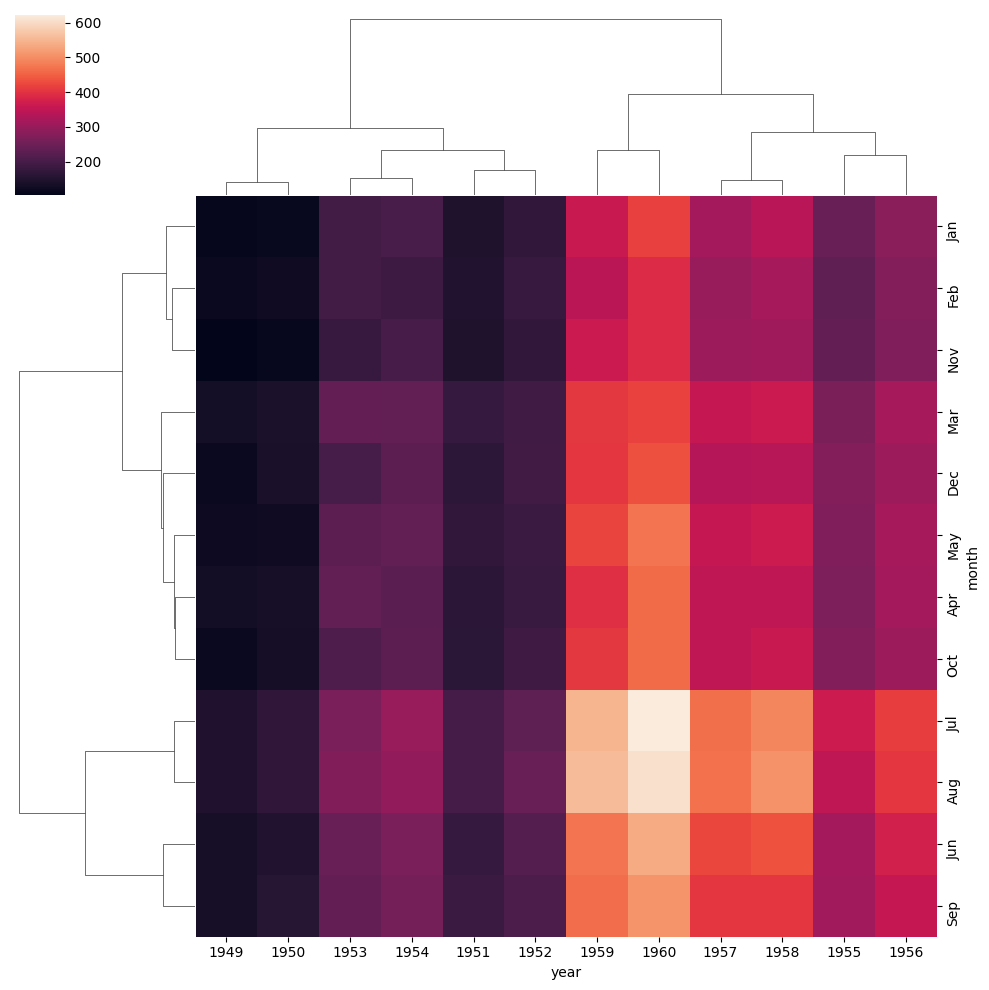

In [44]:
sns.clustermap(flights.pivot_table(values='passengers',index='month',columns='year'))

lighter shades - more passengers